# Thai plate reader on `final_data`: original vs improved, checked against `solution.csv`

**200 held-out plates**: a fixed random sample of the half of `final_data` that was never used to develop, tune or
train the reader (the *test* half, `md5(file name) % 2 == 1`). Each is read by the reader **before** the changes
(the committed `thai_plate_reader.py`) and **after** them, and compared with `solution.csv`.
Within one run, every letter-reading method uses the same segmentation, number and province; only how
the **letters** (e.g. `1กข`) are read changes.

## Summary

The reader runs in four steps:

1. classify the plate as car or motorcycle;
2. locate the plate;
3. locate the letters, number and province fields, and each character;
4. read the fields.

All results below are on held-out images that were never used to develop, tune or train the reader. "Before" is the
original reader on the same images.

**Full plate right** (letters + number + province):

| | before | after |
|---|---|---|
| 200 random held-out images | 15.5% | **58.5%** |
| 300 held-out images ≥ 200 px tall | 20.7% | **57.3%** |

**Each step, given the previous step was right** (section 5):

| step | 200 random | 300 ≥ 200 px |
|---|---|---|
| 1. plate type (car / motorcycle) | 98.0% | 91.7% |
| 2. plate located | 92.9% | 89.5% |
| 3. one box per character: letters / number | 86.3% / 94.0% | 87.4% / 87.8% |
| 3. province box | 94.0% | 95.9% |
| 4. letters / number read | 94.9% / 91.2% | 92.6% / 93.5% |
| 4. province read | 77.2% | 86.4% |

* **Weakest steps:**
  * **province reading**, the smallest text on the plate;
  * **one box per letter**, where touching or broken characters and frame edges cause errors;
  * on large photos, **plate type** and **plate located**, where tilted motorcycle plates fail.
* **How sure:**
  * The step references for misread plates were judged by eye (`benchmark/step_labels.csv`).
  * With 200–300 images, each share is about ±5–7 points.

## 1. Setup

The heavy part, reading every image with every method, is done by `benchmark_final_data.py`. It segments each image
**once**, reads the number and province **once**, then passes the same letter glyphs to every engine.
Ensembles are built from the engines' cached probabilities with the library's own `EnsembleLetters`.
It is resumable and writes one row per image × method:

* `benchmark/final_data_predictions_before.csv`: the original reader (`git show HEAD:thai_plate_reader.py`), all images
* `benchmark/final_data_predictions.csv`: the improved reader, the 200 held-out images

```
python benchmark_final_data.py --split test --sample 200      # the 200 held-out images, ~5 min, 3 workers
```

Scoring happens here, against `solution.csv`.

In [1]:
import hashlib
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from PIL import Image

import thai_plate_reader as tpr

DATA_DIR = Path("/Users/tanut/Desktop/work/get_license_data/data/final_data")
PRED_CSV = Path("benchmark/final_data_predictions.csv")            # improved reader, 200 held-out images
LARGE_CSV = Path("benchmark/final_data_predictions_200px.csv")     # improved reader, 300 held-out images >= 200 px tall
BEFORE_CSV = Path("benchmark/final_data_predictions_before.csv")  # original reader, all images
STEP_LABELS = Path("benchmark/step_labels.csv")                    # by-eye labels for the step-by-step table
RUN_BENCHMARK = False   # True: (re)run / resume the benchmark from here (~5 min)

if RUN_BENCHMARK:
    subprocess.run([sys.executable, "benchmark_final_data.py", "--data", str(DATA_DIR),
                    "--out", str(PRED_CSV), "--split", "test", "--sample", "200"], check=True)

# Thai letters in the figures: DejaVu Sans, falling back to a Thai font (macOS system font; any Thai .ttf works)
for f in ("/System/Library/Fonts/Supplemental/Thonburi.ttc",):
    if Path(f).exists():
        font_manager.fontManager.addfont(f)
plt.rcParams.update({
    "font.family": ["DejaVu Sans", "Thonburi"],
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 110,
})
BLUE, MUTED = "#2a78d6", "#c3c2b7"
pd.set_option("display.max_colwidth", 80)

In [2]:
sol = pd.read_csv(DATA_DIR / "solution.csv", encoding="utf-8-sig", dtype=str, keep_default_na=False)
meta = pd.read_csv(DATA_DIR / "metadata.csv", encoding="utf-8-sig", dtype=str, keep_default_na=False)
meta = meta[["image", "origin", "reg_source", "needs_review"]].rename(
    columns={"needs_review": "label_needs_review"})   # label quality, not the reader's flag
meta["label_needs_review"] = meta["label_needs_review"] == "True"

C = tpr.THAI_CONSONANTS
def plate_format(letters):
    # what the letters look like in the answer
    if letters.isdigit():
        return "bus/truck (30-1234)"
    for name, pat in (("1 consonant (red/old)", f"[{C}]"), ("2 consonants", f"[{C}]{{2}}"),
                      ("digit + consonants", f"[1-9][{C}]{{1,2}}"), ("3 consonants (old moto)", f"[{C}]{{3}}")):
        if re.fullmatch(pat, letters):
            return name
    return "other"

truth = sol.merge(meta, on="image")
truth["format"] = truth["letters"].map(plate_format)
# image size: the photos are plate crops, so their height tracks how many pixels the characters get
truth["width"], truth["height"] = zip(*(Image.open(DATA_DIR / "images" / f).size for f in truth["image"]))
SIZE_GROUPS = ["< 100 px", "100-129 px", "130-159 px", "160-199 px", "200+ px"]
truth["size"] = pd.cut(truth["height"], [0, 100, 130, 160, 200, np.inf], right=False, labels=SIZE_GROUPS)
# the half of the images the fixes were developed on ("dev") and the half kept aside ("test")
truth["split"] = truth["image"].map(lambda f: ("dev", "test")[int(hashlib.md5(f.encode()).hexdigest(), 16) % 2])

def score(path):
    pred = pd.read_csv(path, dtype=str, keep_default_na=False)
    for c in ("letters_conf", "number_conf", "province_posterior", "letters_ms",
              "classify_locate_ms", "fields_ms", "read_ms", "segment_ms", "number_province_ms"):
        if c in pred:
            pred[c] = pd.to_numeric(pred[c], errors="coerce")
    for c in ("needs_review", "letters_format_ok"):
        pred[c] = pred[c] == "True"
    d = pred.merge(truth, on="image", how="inner")
    d["found"] = d["error"] == ""
    d["letters_ok"] = d["letters_pred"] == d["letters"]
    d["number_ok"] = d["number_pred"] == d["numbers"]
    d["province_ok"] = d["province_pred"] == d["province"]
    d["reg_ok"] = d["letters_ok"] & d["number_ok"]
    d["plate_ok"] = d["reg_ok"] & d["province_ok"]
    d["glyphs_ok"] = d["found"] & (pd.to_numeric(d["n_letter_glyphs"], errors="coerce") == d["letters"].str.len())
    return d

df = score(PRED_CSV)
before_all = score(BEFORE_CSV)
before = before_all[before_all["image"].isin(df["image"])]   # the same images
large = score(LARGE_CSV)
before_large = before_all[before_all["image"].isin(large["image"])]
METHODS = list(dict.fromkeys(df["method"]))
DEFAULT = "easyocr+cnn"                          # the reader's default letters engine
per_image = df.drop_duplicates("image")          # method-independent columns
N_IMAGES = df["image"].nunique()
print(f"{N_IMAGES} images, all from the held-out half: {set(df['split']) == {'test'}}")
for name, d in (("before", before), ("after", df)):
    print(f"{name}: methods {', '.join(dict.fromkeys(d['method']))}")

200 images, all from the held-out half: True
before: methods group, easyocr, cnn, tesseract, paddle, easyocr+cnn, cnn+paddle, easyocr+cnn+paddle, easyocr+cnn+tesseract+paddle
after: methods group, easyocr, cnn, tesseract, paddle, easyocr+cnn, cnn+paddle, easyocr+cnn+paddle, easyocr+cnn+tesseract+paddle


## 2. The methods

| method | how the letters are read |
|---|---|
| `group` | EasyOCR reads the whole letters crop in one go (the old behaviour) |
| `easyocr` | EasyOCR, one glyph at a time, each allowed character scored with the CTC likelihood |
| `cnn` | the small font-trained CNN (`thai_letter_cnn.pt`), one glyph at a time |
| `tesseract` | Tesseract 5 LSTM, Thai model, one glyph at a time |
| `paddle` | PaddleOCR's Thai recogniser (PP-OCRv5 mobile), one glyph at a time |
| `a+b…` | weighted average of the engines' per-glyph probabilities (`ENGINE_WEIGHTS`: cnn 2, easyocr 1, paddle 1, tesseract 0.5); `easyocr+cnn` is the reader's default |

As in `ThaiPlateReader.read()`, a per-letter method falls back to `group` when the glyphs look merged or there are more
than 3 of them. In the improved reader every per-letter method is also combined with the field engine's reading of the
whole letters crop (`LINE_WEIGHT`), `group` is read by PaddleOCR, and `cnn` is the retrained model.

## 3. What is in the answer key

The original reader only accepted the letters `[digit?][1–2 consonants]` (motorcycles: also 3 consonants) and numbers
without a leading zero, so it could never read a **bus/truck plate** (`30-1234`, serials such as `0638`) or a red plate
numbered `ก-0327`. The improved reader accepts both.

In [3]:
fmt = truth.groupby("format").agg(images=("image", "size"), example=("letters", "first"))
fmt["share"] = (fmt["images"] / len(truth)).map("{:.1%}".format)
fmt.sort_values("images", ascending=False)

,images,example,share
format,,,
2 consonants,2280,บน,35.9%
digit + consonants,2221,2กฮ,35.0%
1 consonant (red/old),953,ก,15.0%
bus/truck (30-1234),743,31,11.7%
3 consonants (old moto),147,กจก,2.3%


## 4. Before vs after (default letters engine, `easyocr+cnn`)

What changed in `thai_plate_reader.py`:

| problem seen on final_data | change |
|---|---|
| red, yellow and green plates not found (the finder looked for a light-grey rectangle) | plate candidates also from the brightest colour channel, and from the row of large characters (`text_line_quads`) |
| ink mask of the frame instead of the text (blue channel of a yellow plate) | colour channel and polarity judged on the plate's centre with shading removed |
| frame edges and dashes taken as characters; touching characters merged | side-cut components dropped, dashes trimmed, touching glyphs cut, frame bars at the row ends dropped |
| bus/truck `30-1234` and `ก-0327` rejected by the format check | formats added |
| number and province misread by EasyOCR | PaddleOCR's Thai recogniser reads them (`field_engine`) |
| province crop missing parts of the word or including a dealer sticker; "ตาก" as the default guess | the province is read from the band under the top line |
| a bad crop decoded to 12 digits: 4^12 candidates, process killed | candidates capped; extra characters dropped to fit the format |
| the first plate candidate that segmented was used, even when a later one was better | every candidate is segmented and scored on its geometry (`segmentation_score`, weights fitted on the dev half) |
| look-alike letters (ณ/ญ, ท/ห, ฎ/ฏ ...) confused by the font-trained CNN | CNN retrained on fonts **plus real glyphs from the dev half** (`thai_letter_cnn_plates.pt`); per-glyph reading combined with the line recogniser's reading of the whole letters crop |
| `needs_review` thresholds tuned for EasyOCR flagged almost every PaddleOCR reading | thresholds refitted on the dev half |
| tilted motorcycle plates in large photos not found (their rows of characters are slanted) | rows of characters also looked for in copies of the photo turned by ±12° and ±24°; a single row may be either line of a motorcycle plate |
| a character at the very edge of the plate face (under the frame) cut off | enlarged copies (wider and taller) of every light-rectangle candidate |
| the number's greedy decode dropping a digit (`777` -> `7`) | every valid number with the counted number of digits is ranked too |
| large close-up photos took up to 4 minutes | rows of characters searched at 300 px high |
| one function doing everything | four steps: `classify_plate`, `locate_plate`, `locate_fields`, `read_fields` (see section 5) |
| province read as a short name (เลย, ตาก) whenever the crop is blurred: the CTC likelihood favours short names | a bonus per character (`PROVINCE_CHAR_BONUS`), chosen on the dev half as the value that reads the provinces *other than Bangkok* best |
| a consonant broken into two pieces, or the frame edge, read as an extra letter | `refine_letter_boxes`: two close boxes merged, or a thin first box dropped, when the letter CNN reads the result more confidently |

In [4]:
def fields(d):
    d = d[d["method"] == DEFAULT]
    return pd.Series({"plate found": d["found"].mean(), "letters": d["letters_ok"].mean(),
                      "number": d["number_ok"].mean(), "province": d["province_ok"].mean(),
                      "letters + number": d["reg_ok"].mean(), "full plate": d["plate_ok"].mean()})

ba = pd.DataFrame({"before": fields(before), "after": fields(df)})
ba["change"] = ba["after"] - ba["before"]
ba.style.format("{:.1%}", subset=["before", "after"]).format("{:+.1%}", subset=["change"])

,before,after,change
plate found,61.0%,99.5%,+38.5%
letters,24.0%,77.5%,+53.5%
number,37.5%,82.0%,+44.5%
province,26.5%,68.0%,+41.5%
letters + number,22.5%,72.5%,+50.0%
full plate,15.5%,58.5%,+43.0%


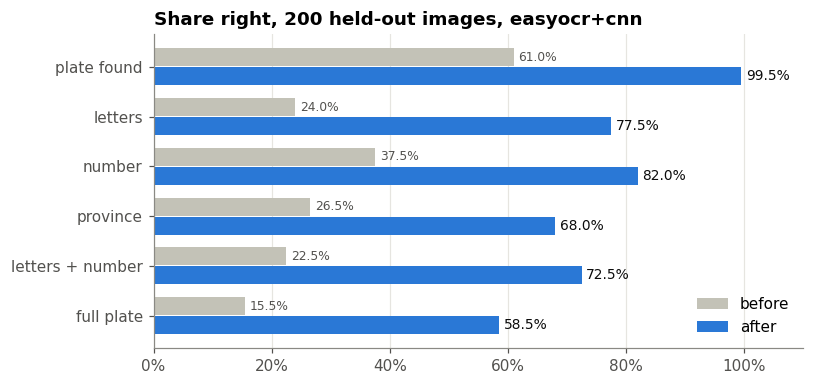

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
y = np.arange(len(ba))[::-1]
ax.barh(y + 0.19, ba["before"], height=0.36, color=MUTED, label="before")
ax.barh(y - 0.19, ba["after"], height=0.36, color=BLUE, label="after")
for yi, b, a in zip(y, ba["before"], ba["after"]):
    ax.text(a + 0.008, yi - 0.19, f"{a:.1%}", va="center", fontsize=9, color="#0b0b0b")
    ax.text(b + 0.008, yi + 0.19, f"{b:.1%}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, ba.index)
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Share right, {N_IMAGES} held-out images, {DEFAULT}", loc="left")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", color="#e6e5e0", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [6]:
# full plate right, by plate format
def by(d, col):
    return d[d["method"] == DEFAULT].groupby(col)["plate_ok"].mean()
t = pd.DataFrame({"images": truth["format"].value_counts(),
                  "before": by(before, "format"), "after": by(df, "format")}).sort_values("images", ascending=False)
t.style.format("{:.1%}", subset=["before", "after"])

,images,before,after
format,,,
2 consonants,2280,20.3%,53.6%
digit + consonants,2221,23.5%,66.2%
1 consonant (red/old),953,0.0%,36.7%
bus/truck (30-1234),743,0.0%,75.0%
3 consonants (old moto),147,20.0%,60.0%


These are honest held-out figures: the fixes were developed by looking at failures in the other half of the images
(**dev**, `md5(file name) % 2 == 0`), the candidate-scoring weights and `needs_review` thresholds were fitted on it, and
the CNN was trained on its glyphs. With 200 images, a share of about 50% has a 95% margin of roughly ±7 points.

### By image size

Images grouped by their **height in pixels** (the photos are plate crops, so the height tracks how many pixels the
characters get). Default letters engine; *before* is the original reader. The groups are small (see *images*), so
read the trend rather than single values.

In [7]:
def by_size(d):
    d = d[d["method"] == DEFAULT]
    g = d.groupby("size", observed=False)
    return pd.DataFrame({"images": g.size(), "plate found": g["found"].mean(),
                         "letters": g["letters_ok"].mean(), "number": g["number_ok"].mean(),
                         "province": g["province_ok"].mean(), "full plate": g["plate_ok"].mean()})

def size_table(after, before_):
    t = by_size(after)
    t.insert(len(t.columns), "full plate (before)", by_size(before_)["full plate"])
    pct = [c for c in t.columns if c != "images"]
    return (t.style.format("{:.1%}", subset=pct)
            .background_gradient(cmap="Blues", subset=pct, vmin=0, vmax=1))

size_table(df, before)

,images,plate found,letters,number,province,full plate,full plate (before)
size,,,,,,,
< 100 px,31,100.0%,80.6%,87.1%,64.5%,58.1%,6.5%
100-129 px,45,97.8%,80.0%,80.0%,53.3%,48.9%,15.6%
130-159 px,50,100.0%,86.0%,88.0%,74.0%,70.0%,20.0%
160-199 px,44,100.0%,63.6%,77.3%,70.5%,50.0%,13.6%
200+ px,30,100.0%,76.7%,76.7%,80.0%,66.7%,20.0%


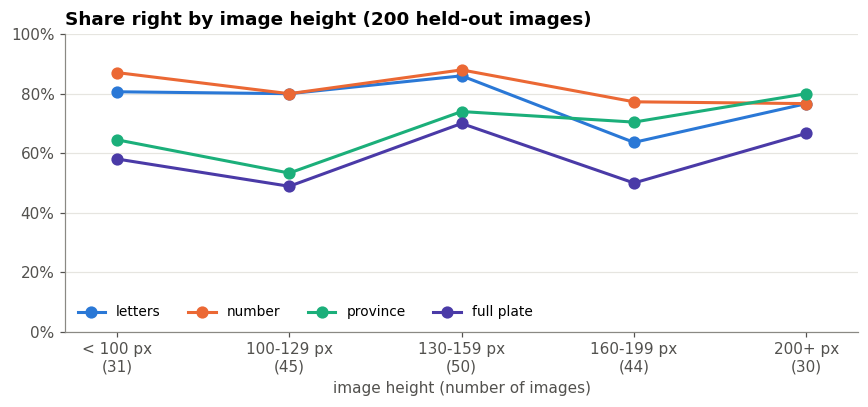

In [8]:
t = by_size(df)
series = [("letters", "#2a78d6"), ("number", "#eb6834"), ("province", "#1baf7a"), ("full plate", "#4a3aa7")]
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(t))
for name, colour in series:
    ax.plot(x, t[name], color=colour, lw=2, marker="o", ms=7, label=name)
ax.set_xticks(x, [f"{g}\n({n:,})" for g, n in zip(t.index, t["images"])])
ax.set_xlim(-0.3, len(t) - 0.7)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Share right by image height ({N_IMAGES} held-out images)", loc="left")
ax.set_xlabel("image height (number of images)")
ax.legend(loc="lower left", frameon=False, ncol=4, fontsize=9)
ax.grid(axis="y", color="#e6e5e0", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Large photos: 300 held-out images at least 200 px tall

A fixed random sample of the held-out half's photos that are 200 px or taller (585 such photos in that half; 1,123 in all of
`final_data`). Half of them are motorcycle plates, whose photos are taller than wide.

In [9]:
ba_large = pd.DataFrame({"before": fields(before_large), "after": fields(large)})
ba_large["change"] = ba_large["after"] - ba_large["before"]
print(f"{large['image'].nunique()} images, all from the held-out half: {set(large['split']) == {'test'}}")
ba_large.style.format("{:.1%}", subset=["before", "after"]).format("{:+.1%}", subset=["change"])

300 images, all from the held-out half: True


,before,after,change
plate found,53.7%,97.0%,+43.3%
letters,30.3%,70.7%,+40.3%
number,34.3%,71.7%,+37.3%
province,31.0%,71.7%,+40.7%
letters + number,26.0%,63.7%,+37.7%
full plate,20.7%,57.3%,+36.7%


In [10]:
def by_height(d):
    d = d[d["method"] == DEFAULT]
    g = d.groupby(pd.cut(d["height"], [200, 300, 600, np.inf], right=False,
                         labels=["200-299 px", "300-599 px", "600+ px"]), observed=False)
    return pd.DataFrame({"images": g.size(), "plate found": g["found"].mean(), "letters": g["letters_ok"].mean(),
                         "number": g["number_ok"].mean(), "province": g["province_ok"].mean(),
                         "full plate": g["plate_ok"].mean()})
t = by_height(large)
t["full plate (before)"] = by_height(before_large)["full plate"]
t.style.format("{:.1%}", subset=[c for c in t.columns if c != "images"])

,images,plate found,letters,number,province,full plate,full plate (before)
height,,,,,,,
200-299 px,243,97.9%,70.0%,72.4%,70.8%,55.6%,19.3%
300-599 px,33,87.9%,69.7%,60.6%,66.7%,60.6%,24.2%
600+ px,24,100.0%,79.2%,79.2%,87.5%,70.8%,29.2%


## 5. The pipeline, step by step

`ThaiPlateReader.read()` runs four steps, each also available as a function:

1. **`classify_plate`**: car or motorcycle plate
2. **`locate_plate`**: the plate's quad, warped flat
3. **`locate_fields`**: the letters, number and province boxes, and one box per character of the letters and the number
4. **`read_fields`**: the letters (one character at a time, or the whole crop when the characters are merged), the
   number (as a group, ranking the strings of the counted length), the province

Each step is scored **only on the images where the previous step was right**.
`solution.csv` holds only the final text, so the reference for the earlier steps is:

* **plate type** and **plate located**: judged by eye for every image whose letters or number were misread
  (`benchmark/step_labels.csv`; labels of an image whose chosen plate region did not change between versions were
  carried over); an image whose letters and number were both read right counts as correctly classified and located. *Plate located* means the warped plate contains every character of the plate. A photo where nothing
  was found counts as a step-1 failure.
* **one box per character**: the number of letter / digit boxes equals the length of the answer (checked automatically).
* **province box**: judged by eye when the province was misread; right when the province was read right.

In [11]:
labels = pd.read_csv(STEP_LABELS, dtype=str, keep_default_na=False)

def step_table(d):
    d = d[d["method"] == DEFAULT].merge(labels, on="image", how="left").fillna(
        {"plate_type": "", "plate_located": "", "province_box": ""})
    L, N, P = d["letters_ok"], d["number_ok"], d["province_ok"]
    verified = L & N            # letters and number read right: plate type and location were right
    s1 = d["found"] & (d["layout"] == d["plate_type"].where(d["plate_type"] != "", d["layout"]))
    s2 = s1 & (verified | (d["plate_located"] == "1"))
    lbox = pd.to_numeric(d["n_letter_glyphs"], errors="coerce") == d["letters"].str.len()
    nbox = pd.to_numeric(d["n_number_glyphs"], errors="coerce") == d["numbers"].str.len()
    pbox = (verified & P) | (d["province_box"] == "1")
    every = pd.Series(True, index=d.index)
    rows = [("1. plate type: car / motorcycle", "-", every, s1),
            ("2. plate located", "plate type right", s1, s2),
            ("3. letters: one box per character", "plate located", s2, s2 & lbox),
            ("3. number: one box per character", "plate located", s2, s2 & nbox),
            ("3. province box", "plate located", s2, s2 & pbox),
            ("4. letters read", "letter boxes right", s2 & lbox, s2 & lbox & L),
            ("4. number read", "number boxes right", s2 & nbox, s2 & nbox & N),
            ("4. province read", "province box right", s2 & pbox, s2 & pbox & P),
            ("end to end: full plate right", "-", every, L & N & P)]
    t = pd.DataFrame([(a, b, int(base.sum()), int(ok.sum())) for a, b, base, ok in rows],
                     columns=["step", "given", "images", "right"]).set_index("step")
    t["accuracy"] = t["right"] / t["images"]
    return t

step_tables = pd.concat({f"{df['image'].nunique()} random held-out images": step_table(df),
                         f"{large['image'].nunique()} held-out images >= 200 px": step_table(large)}, axis=1)
step_tables.style.format("{:.1%}", subset=[c for c in step_tables.columns if c[1] == "accuracy"])

* The weakest step is still **reading the province** once its box is right, although the per-character bonus lifted it by
  about 8 points: the province is the smallest text on the plate and often only a few pixels high. Other crops (colour,
  contrast-enhanced, shifted, widened to the ink) all read worse than the current band on a separate validation set; a
  better province reader would need a recogniser trained on plate provinces.
* On large photos most losses are earlier: **plate type** (motorcycle plates read as car plates and the reverse) and
  **plate located** (tilted motorcycle plates cut at a side).

## 6. Headline: accuracy per letters method (improved reader)

* **letters**: the letters string is exactly right
* **letters + number**: the registration is right
* **full plate**: letters + number + province (the province in `solution.csv` is itself OCR, ~97% right)
* **letters, glyphs right**: letters accuracy on plates that were segmented into the right number of letter glyphs.
  This isolates the engine from the segmentation.

In [12]:
def summary(d):
    g = d.groupby("method", sort=False)
    out = pd.DataFrame({
        "letters": g["letters_ok"].mean(),
        "letters + number": g["reg_ok"].mean(),
        "full plate": g["plate_ok"].mean(),
        "letters, plate found": d[d["found"]].groupby("method", sort=False)["letters_ok"].mean(),
        "letters, glyphs right": d[d["glyphs_ok"]].groupby("method", sort=False)["letters_ok"].mean(),
        "letters ms (median)": d[d["found"]].groupby("method", sort=False)["letters_ms"].median(),
    })
    return out.sort_values("letters", ascending=False)

headline = summary(df)
headline.insert(1, "letters (before)", before.groupby("method")["letters_ok"].mean())
pct = [c for c in headline.columns if "ms" not in c]
(headline.style.format("{:.1%}", subset=pct).format("{:.0f}", subset=["letters ms (median)"])
 .background_gradient(cmap="Blues", subset=pct, vmin=0, vmax=1))

,letters,letters (before),letters + number,full plate,"letters, plate found","letters, glyphs right",letters ms (median)
method,,,,,,,
cnn,78.0%,21.0%,73.0%,58.0%,78.4%,92.8%,2
easyocr+cnn,77.5%,24.0%,72.5%,58.5%,77.9%,92.2%,335
cnn+paddle,77.5%,24.0%,72.5%,57.5%,77.9%,92.2%,157
easyocr+cnn+paddle,77.0%,24.5%,72.0%,58.0%,77.4%,91.6%,506
easyocr+cnn+tesseract+paddle,75.0%,25.0%,70.0%,57.0%,75.4%,89.2%,740
easyocr,49.5%,21.0%,47.0%,39.0%,49.7%,58.4%,333
group,48.5%,20.0%,46.5%,38.5%,48.7%,57.2%,77
paddle,40.0%,11.0%,38.5%,32.5%,40.2%,47.0%,154
tesseract,33.0%,16.5%,32.0%,26.0%,33.2%,38.6%,221


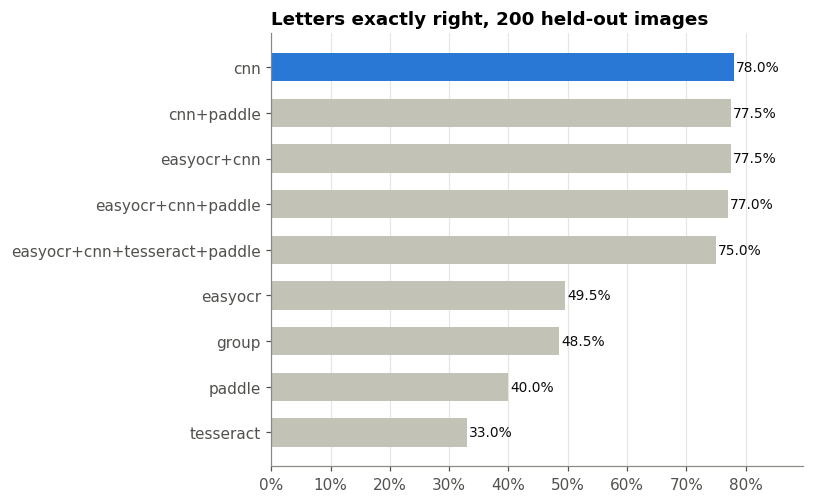

In [13]:
h = headline["letters"].sort_values()
best = h.index[-1]
fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(h) + 0.9))
ax.barh(h.index, h.values, height=0.62, color=[BLUE if m == best else MUTED for m in h.index])
for y, v in enumerate(h.values):
    ax.text(v + 0.004, y, f"{v:.1%}", va="center", fontsize=9, color="#0b0b0b")
ax.set_xlim(0, max(h.max() * 1.15, 0.1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Letters exactly right, {N_IMAGES} held-out images", loc="left")
ax.grid(axis="x", color="#e6e5e0", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Excluding labels flagged for review

The same table for plates whose label is **not** flagged `needs_review` in `metadata.csv`.

In [14]:
clean = df[~df["label_needs_review"]]
print(f"{clean['image'].nunique():,} images")
t = summary(clean)
t_pct = [c for c in t.columns if "ms" not in c]
(t.style.format("{:.1%}", subset=t_pct).format("{:.0f}", subset=["letters ms (median)"])
 .background_gradient(cmap="Blues", subset=t_pct, vmin=0, vmax=1))

190 images


,letters,letters + number,full plate,"letters, plate found","letters, glyphs right",letters ms (median)
method,,,,,,
cnn,77.9%,73.2%,58.9%,78.3%,92.4%,2
easyocr+cnn,77.4%,72.6%,59.5%,77.8%,91.8%,335
cnn+paddle,77.4%,72.6%,58.4%,77.8%,91.8%,157
easyocr+cnn+paddle,76.8%,72.1%,58.9%,77.2%,91.1%,506
easyocr+cnn+tesseract+paddle,74.7%,70.0%,57.9%,75.1%,88.6%,748
easyocr,48.4%,46.3%,39.5%,48.7%,57.0%,333
group,47.4%,45.8%,38.4%,47.6%,55.7%,77
paddle,39.5%,38.4%,33.2%,39.7%,46.2%,154
tesseract,32.1%,31.6%,26.3%,32.3%,37.3%,222


## 7. Where plates are lost, before the letter engine matters

Segmentation, the number and the province are the same for every method. Each bar is the share of the images;
the letters and full-plate bars are for the best method.

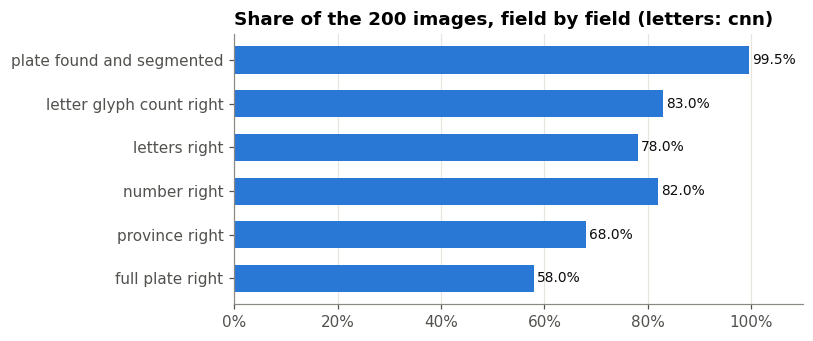

In [15]:
pi = per_image
steps = pd.Series({
    "plate found and segmented": pi["found"].mean(),
    "letter glyph count right": pi["glyphs_ok"].mean(),
    "letters right": df[df["method"] == best]["letters_ok"].mean(),
    "number right": pi["number_ok"].mean(),
    "province right": pi["province_ok"].mean(),
    "full plate right": df[df["method"] == best]["plate_ok"].mean(),
})
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(steps.index[::-1], steps.values[::-1], height=0.62, color=BLUE)
for y, v in enumerate(steps.values[::-1]):
    ax.text(v + 0.006, y, f"{v:.1%}", va="center", fontsize=9, color="#0b0b0b")
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Share of the {N_IMAGES} images, field by field (letters: {best})", loc="left")
ax.grid(axis="x", color="#e6e5e0", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [16]:
# why segmentation failed (PlateNotFound messages)
reasons = pi.loc[~pi["found"], "error"].str.replace(r"^\w+: ", "", regex=True).value_counts()
pd.DataFrame({"images": reasons, "share of all": (reasons / len(pi)).map("{:.1%}".format)})

,images,share of all
error,,
could not find the large characters of the top line,1,0.5%


In [17]:
# segmentation and the layout chosen, by plate format
seg = pi.groupby("format").agg(images=("image", "size"), plate_found=("found", "mean"),
                               glyph_count_right=("glyphs_ok", "mean"),
                               read_as_motorcycle=("layout", lambda s: (s == "motorcycle").mean()))
seg.sort_values("images", ascending=False).style.format("{:.1%}", subset=seg.columns[1:])

,images,plate_found,glyph_count_right,read_as_motorcycle
format,,,,
2 consonants,69,100.0%,91.3%,1.4%
digit + consonants,68,98.5%,77.9%,26.5%
1 consonant (red/old),30,100.0%,70.0%,3.3%
bus/truck (30-1234),28,100.0%,92.9%,0.0%
3 consonants (old moto),5,100.0%,60.0%,100.0%


## 8. Letters accuracy by plate format and by image origin

In [18]:
order = headline.index
by_fmt = df.pivot_table(index="format", columns="method", values="letters_ok", aggfunc="mean")[order]
by_fmt.insert(0, "images", truth["format"].value_counts())
by_fmt = by_fmt.sort_values("images", ascending=False)
by_fmt.style.format("{:.1%}", subset=list(order)).background_gradient(cmap="Blues", subset=list(order), vmin=0, vmax=1)

method,images,cnn,easyocr+cnn,cnn+paddle,easyocr+cnn+paddle,easyocr+cnn+tesseract+paddle,easyocr,group,paddle,tesseract
format,,,,,,,,,,
2 consonants,2280,85.5%,85.5%,84.1%,84.1%,78.3%,52.2%,40.6%,23.2%,33.3%
digit + consonants,2221,75.0%,73.5%,75.0%,75.0%,75.0%,52.9%,51.5%,41.2%,35.3%
1 consonant (red/old),953,56.7%,56.7%,60.0%,56.7%,56.7%,43.3%,26.7%,33.3%,26.7%
bus/truck (30-1234),743,92.9%,92.9%,92.9%,92.9%,92.9%,50.0%,89.3%,89.3%,39.3%
3 consonants (old moto),147,60.0%,60.0%,40.0%,40.0%,40.0%,0.0%,20.0%,20.0%,0.0%


In [19]:
by_org = df.pivot_table(index="origin", columns="method", values="letters_ok", aggfunc="mean")[order]
by_org.insert(0, "images", truth["origin"].value_counts())
by_org.style.format("{:.1%}", subset=list(order)).background_gradient(cmap="Blues", subset=list(order), vmin=0, vmax=1)

method,images,cnn,easyocr+cnn,cnn+paddle,easyocr+cnn+paddle,easyocr+cnn+tesseract+paddle,easyocr,group,paddle,tesseract
origin,,,,,,,,,,
closeup,114,0.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
crop_full_vehicle,5235,79.3%,78.7%,78.7%,78.1%,76.3%,50.3%,49.1%,40.2%,32.0%
crop_multi_plate,995,73.3%,70.0%,70.0%,70.0%,66.7%,43.3%,43.3%,36.7%,36.7%


## 9. Can the reader's `needs_review` flag be trusted?

For each method: how many plates it flags, how accurate the **unflagged** plates are (letters + number), and what share
of all its registration errors the flag catches.

In [20]:
f = df[df["found"]]
g = f.groupby("method", sort=False)
review = pd.DataFrame({
    "flagged": g["needs_review"].mean(),
    "right when not flagged": f[~f["needs_review"]].groupby("method", sort=False)["reg_ok"].mean(),
    "right when flagged": f[f["needs_review"]].groupby("method", sort=False)["reg_ok"].mean(),
    "errors caught by flag": f[~f["reg_ok"]].groupby("method", sort=False)["needs_review"].mean(),
}).loc[order]
review.style.format("{:.1%}")

,flagged,right when not flagged,right when flagged,errors caught by flag
method,,,,
cnn,61.8%,97.4%,58.5%,96.2%
easyocr+cnn,65.3%,98.6%,59.2%,98.1%
cnn+paddle,72.4%,100.0%,62.5%,100.0%
easyocr+cnn+paddle,70.9%,100.0%,61.0%,100.0%
easyocr+cnn+tesseract+paddle,71.4%,100.0%,58.5%,100.0%
easyocr,69.3%,80.3%,32.6%,88.6%
group,86.9%,84.6%,41.0%,96.2%
paddle,74.9%,76.0%,26.2%,90.2%
tesseract,70.4%,59.3%,20.7%,82.2%


In [21]:
# ensembles: does engine agreement predict a right answer?
ens = df[df["by_engine"].str.contains("=") & df["letters_mode"].eq("per-letter")].copy()
ens["agree"] = ens["by_engine"].map(lambda s: len({p.split("=", 1)[1] for p in s.split("|")}) == 1)
agree = ens.groupby("method", sort=False).apply(lambda d: pd.Series({
    "engines agree": d["agree"].mean(),
    "letters right when they agree": d.loc[d["agree"], "letters_ok"].mean(),
    "letters right when they disagree": d.loc[~d["agree"], "letters_ok"].mean(),
}), include_groups=False)
agree.style.format("{:.1%}")

,engines agree,letters right when they agree,letters right when they disagree
method,,,
easyocr+cnn,50.5%,92.9%,62.9%
cnn+paddle,41.8%,90.2%,69.3%
easyocr+cnn+paddle,30.1%,91.5%,71.5%
easyocr+cnn+tesseract+paddle,16.8%,97.0%,71.2%


## 10. Speed

Median milliseconds per plate for the letters only, measured with 3 worker processes sharing the CPU, so compare the
methods with each other rather than with single-plate timings. Steps 1-3 and the number and province are the same for every method.

In [22]:
speed = df[df["found"]].groupby("method", sort=False)["letters_ms"].median().loc[order].round(0).to_frame("letters ms")
speed["letters right"] = headline["letters"].map("{:.1%}".format)
print(f"steps 1-2 (classify + locate): {pi['classify_locate_ms'].astype(float).median():.0f} ms, "
      f"step 4 (read, default engine): {pi['read_ms'].astype(float).median():.0f} ms (median per plate)")
speed

steps 1-2 (classify + locate): 294 ms, step 4 (read, default engine): 266 ms (median per plate)


,letters ms,letters right
method,,
cnn,2.0,78.0%
easyocr+cnn,335.0,77.5%
cnn+paddle,157.0,77.5%
easyocr+cnn+paddle,506.0,77.0%
easyocr+cnn+tesseract+paddle,740.0,75.0%
easyocr,333.0,49.5%
group,77.0,48.5%
paddle,154.0,40.0%
tesseract,221.0,33.0%


## 11. Which letters get confused

Glyph-by-glyph comparison for plates whose prediction has the right length, using the best method.

In [23]:
b = df[(df["method"] == best) & df["found"] & (df["letters_pred"].str.len() == df["letters"].str.len())]
pairs = [(t, p) for tt, pp in zip(b["letters"], b["letters_pred"]) for t, p in zip(tt, pp) if t != p]
conf = pd.Series(pairs).value_counts().head(20)
conf.index = [f"{t} → {p}" for t, p in conf.index]
print(f"{best}: {len(pairs)} wrong glyphs out of {b['letters'].str.len().sum():,} "
      f"({len(pairs) / max(1, b['letters'].str.len().sum()):.1%})")
conf.to_frame("times (truth → read)")

cnn: 14 wrong glyphs out of 371 (3.8%)


,times (truth → read)
พ → ผ,1
ภ → ก,1
ภ → ฮ,1
ฬ → ก,1
ภ → ฏ,1
ก → 5,1
อ → 6,1
ศ → 6,1
ณ → 1,1
ฌ → 1,1


In [24]:
# per-character accuracy (as the truth), worst first, characters seen at least 20 times
rows = [(t, t == p) for tt, pp in zip(b["letters"], b["letters_pred"]) for t, p in zip(tt, pp)]
ch = pd.DataFrame(rows, columns=["char", "ok"]).groupby("char")["ok"].agg(["size", "mean"])
ch = ch[ch["size"] >= 20].sort_values("mean").head(15)
ch.rename(columns={"size": "seen", "mean": "read right"}).style.format({"read right": "{:.1%}"})

,seen,read right
char,,
ก,49,98.0%
1,33,100.0%
ข,48,100.0%


## 12. Examples of mistakes (best method)

Random wrong plates that the reader did find; the title is `truth → read`.

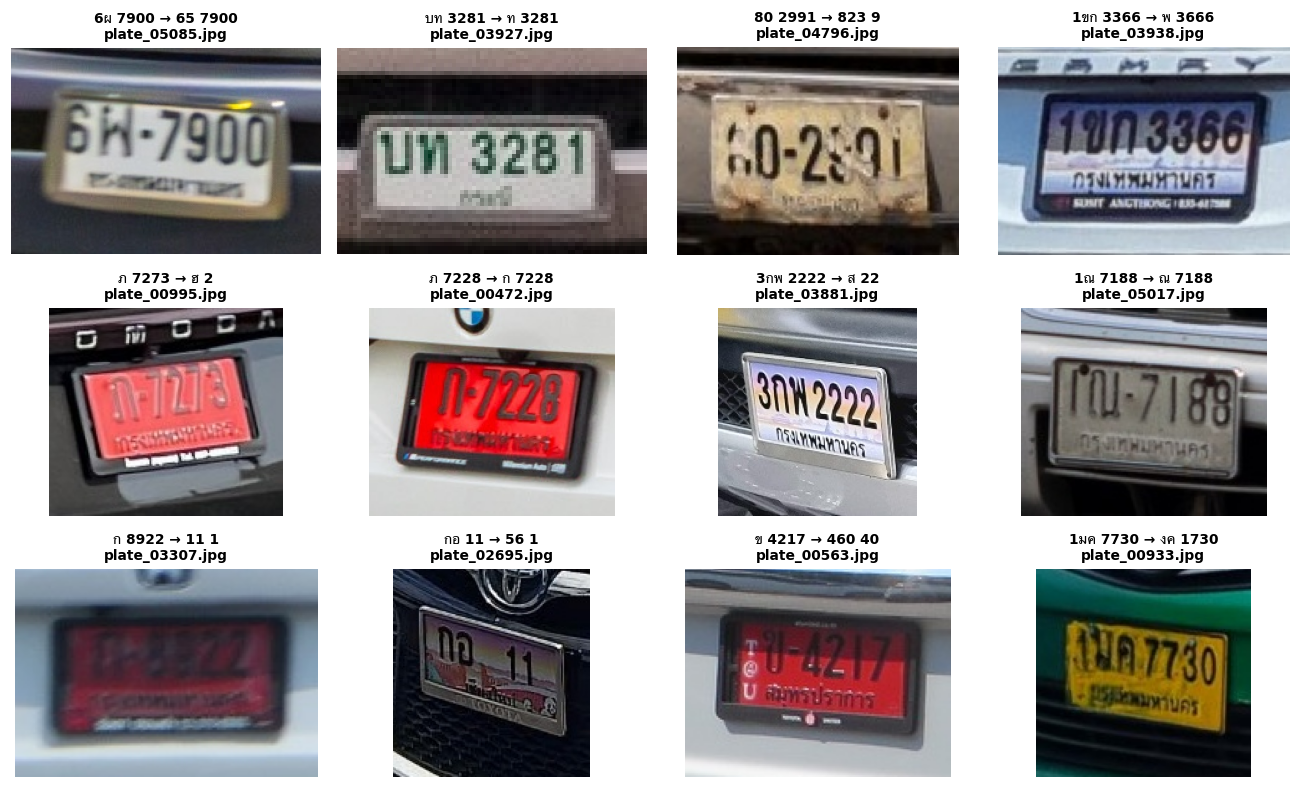

In [25]:
wrong = df[(df["method"] == best) & df["found"] & ~df["reg_ok"]]
sample = wrong.sample(min(12, len(wrong)), random_state=0)
fig, axes = plt.subplots(3, 4, figsize=(12, 7.2))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    im = tpr.imread(DATA_DIR / "images" / r["image"])
    ax.imshow(im[..., ::-1])
    ax.set_title(f"{r['letters']} {r['numbers']} → {r['letters_pred']} {r['number_pred']}\n{r['image']}",
                 fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

plate_05085.jpg | truth: 6ผ 7900 กรุงเทพมหานคร | read: 65 7900 มหาสารคาม | per-letter (cnn) 


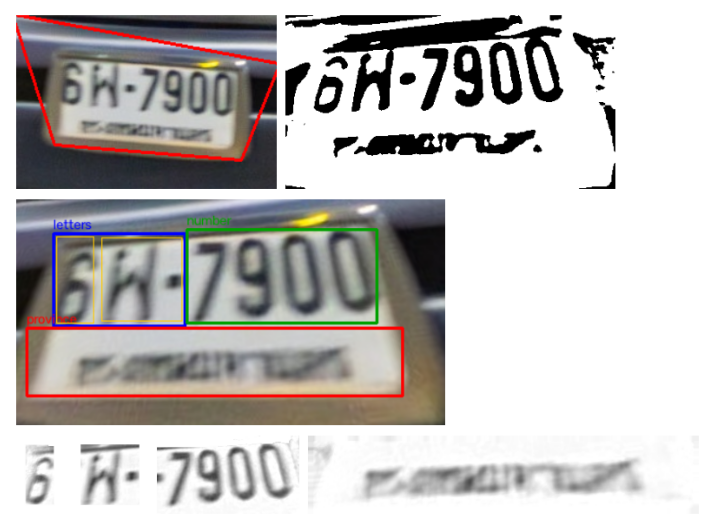

In [26]:
# look at one plate in detail: the debug sheet shows the plate found, the boxes and the exact glyphs read
IMAGE = sample.iloc[0]["image"] if len(sample) else sol["image"].iloc[0]
reader = tpr.ThaiPlateReader(letters_engine=best if best != "group" else "group")
res = reader.read(str(DATA_DIR / "images" / IMAGE), return_debug=True)
print(IMAGE, "| truth:", *sol.set_index("image").loc[IMAGE], "| read:", res["plate"], res["province"],
      "|", res["letters_detail"]["mode"], res["letters_detail"]["by_engine"] or "")
plt.figure(figsize=(10, 6)); plt.imshow(tpr.debug_sheet(res.pop("_debug"))[..., ::-1]); plt.axis("off"); plt.show()

In [27]:
# every row for your own filtering, e.g. errors of one method on one plate format
cols = ["image", "method", "format", "letters", "letters_pred", "numbers", "number_pred",
        "province", "province_pred", "letters_mode", "by_engine", "needs_review", "error"]
df.loc[(df["method"] == best) & ~df["plate_ok"], cols].head(20)

,image,method,format,letters,letters_pred,numbers,number_pred,province,province_pred,letters_mode,by_engine,needs_review,error
2,plate_00010.jpg,cnn,1 consonant (red/old),พ,ผ,2400,2400,กรุงเทพมหานคร,กรุงเทพมหานคร,per-letter,,True,
11,plate_00120.jpg,cnn,bus/truck (30-1234),10,10,0499,0499,นนทบุรี,อ่างทอง,per-letter,,True,
20,plate_00135.jpg,cnn,bus/truck (30-1234),34,34,1573,1573,กรุงเทพมหานคร,นครนายก,per-letter,,True,
29,plate_00169.jpg,cnn,2 consonants,บร,บร,5309,5309,เพชรบุรี,ยะลา,per-letter,,True,
92,plate_00352.jpg,cnn,digit + consonants,1มข,ข,4,,กรุงเทพมหานคร,เลย,per-letter,,True,
128,plate_00472.jpg,cnn,1 consonant (red/old),ภ,ก,7228,7228,นนทบุรี,กรุงเทพมหานคร,per-letter,,True,
164,plate_00561.jpg,cnn,1 consonant (red/old),ล,1ล,5509,5509,กรุงเทพมหานคร,เลย,per-letter,,True,
173,plate_00563.jpg,cnn,1 consonant (red/old),ข,460,4217,40,สมุทรปราการ,หนองคาย,per-letter,,True,
209,plate_00700.jpg,cnn,1 consonant (red/old),ก,ก,6969,6959,ภูเก็ต,ภูเก็ต,per-letter,,True,
245,plate_00736.jpg,cnn,1 consonant (red/old),ฐ,ฐ1,1129,1297,กรุงเทพมหานคร,กรุงเทพมหานคร,per-letter,,True,
